In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../data/processed/weather_features.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,temperature_2m_max,temperature_2m_min,precipitation_sum,temperature_mean,humidity_mean,pressure_mean,wind_speed_mean,precipitation_hourly_sum,temperature_lag_1,temperature_lag_3,temperature_lag_7,temperature_rolling_3,temperature_rolling_7,humidity_rolling_3,pressure_rolling_3,day_of_week,month,target_next_day_max_temp
0,2022-01-08,27.6,18.0,0.3,22.000000,72.750000,1015.225000,11.425000,0.3,27.6,27.6,27.8,27.566667,27.385714,69.527778,1015.069444,5,1,28.7
1,2022-01-09,28.7,18.0,0.4,22.508333,70.583333,1013.383333,8.841667,0.4,27.6,27.5,27.1,27.966667,27.614286,70.583333,1014.523611,6,1,26.5
2,2022-01-10,26.5,18.2,3.0,21.400000,79.625000,1013.962500,7.333333,3.0,28.7,27.6,27.3,27.600000,27.500000,74.319444,1014.190278,0,1,26.6
3,2022-01-11,26.6,17.3,4.9,20.820833,82.958333,1013.758333,10.608333,4.9,26.5,27.6,27.0,27.266667,27.442857,77.722222,1013.701389,1,1,26.1
4,2022-01-12,26.1,17.0,1.5,20.275000,83.583333,1013.520833,8.545833,1.5,26.6,28.7,27.6,26.400000,27.228571,82.055556,1013.747222,2,1,24.1


In [3]:
print(df.shape)
print(df["date"].min())
print(df["date"].max())

(1453, 19)
2022-01-08 00:00:00
2025-12-30 00:00:00


In [4]:
features = [
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "temperature_mean",
    "humidity_mean",
    "pressure_mean",
    "wind_speed_mean",
    "precipitation_hourly_sum",
    "temperature_lag_1",
    "temperature_lag_3",
    "temperature_lag_7",
    "temperature_rolling_3",
    "temperature_rolling_7",
    "humidity_rolling_3",
    "pressure_rolling_3",
    "day_of_week",
    "month"
]

target = "target_next_day_max_temp"

X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(1453, 17)
(1453,)


In [6]:
regression_model = joblib.load(
    "../../Week5/models/regression_model.pkl"
)

print("Regression model loaded successfully.")

Regression model loaded successfully.


In [7]:
split_index = int(len(df) * 0.8)

print("Initial training rows:", split_index)
print("Backtest rows:", len(df) - split_index)

Initial training rows: 1162
Backtest rows: 291


In [8]:
regression_results = []

for i in range(split_index, len(df)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    X_test = X.iloc[[i]]
    actual = y.iloc[i]

    regression_model.fit(X_train, y_train)

    prediction = regression_model.predict(X_test)[0]

    regression_results.append({
        "date": df["date"].iloc[i],
        "actual": actual,
        "predicted_regression": prediction
    })

regression_results = pd.DataFrame(regression_results)

regression_results.head()

,date,actual,predicted_regression
0,2025-03-15,37.2,37.084274
1,2025-03-16,37.6,37.129127
2,2025-03-17,37.0,37.473314
3,2025-03-18,36.1,37.031483
4,2025-03-19,35.3,36.384392


In [9]:
regression_mae = mean_absolute_error(
    regression_results["actual"],
    regression_results["predicted_regression"]
)

regression_mse = mean_squared_error(
    regression_results["actual"],
    regression_results["predicted_regression"]
)

regression_rmse = np.sqrt(regression_mse)

print("Linear Regression Backtest")
print("MAE:", regression_mae)
print("MSE:", regression_mse)
print("RMSE:", regression_rmse)

Linear Regression Backtest
MAE: 0.8891688390455703
MSE: 1.5084213357690468
RMSE: 1.2281780554011892


In [10]:
temperature_series = (
    df[["date", "temperature_2m_max"]]
    .set_index("date")["temperature_2m_max"]
)

In [11]:
arima_results = []

for i in range(split_index, len(temperature_series)):
    train_series = temperature_series.iloc[:i]

    actual = df["target_next_day_max_temp"].iloc[i]

    model = ARIMA(train_series, order=(1, 1, 1))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=1)
    prediction = forecast.iloc[0]

    arima_results.append({
        "date": df["date"].iloc[i],
        "actual": actual,
        "predicted_arima": prediction
    })

arima_results = pd.DataFrame(arima_results)

arima_results.head()

d:\ESWAR\AIML-Internship-(EDP)\Weather-Prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\ESWAR\AIML-Internship-(EDP)\Weather-Prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\ESWAR\AIML-Internship-(EDP)\Weather-Prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\ESWAR\AIML-Internship-(EDP)\Weather-Prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\ESWAR\AIML-Internship-(EDP)\Weather-Prediction\.venv\

,date,actual,predicted_arima
0,2025-03-15,37.2,36.873383
1,2025-03-16,37.6,36.956696
2,2025-03-17,37.0,36.864422
3,2025-03-18,36.1,37.242766
4,2025-03-19,35.3,36.812151


In [12]:
arima_mae = mean_absolute_error(
    arima_results["actual"],
    arima_results["predicted_arima"]
)

arima_mse = mean_squared_error(
    arima_results["actual"],
    arima_results["predicted_arima"]
)

arima_rmse = np.sqrt(arima_mse)

print("ARIMA Backtest")
print("MAE:", arima_mae)
print("MSE:", arima_mse)
print("RMSE:", arima_rmse)

ARIMA Backtest
MAE: 1.2347534304443113
MSE: 2.7419360503780887
RMSE: 1.6558792378606868


In [13]:
backtest_results = regression_results.merge(
    arima_results,
    on=["date", "actual"]
)

backtest_results.head()

,date,actual,predicted_regression,predicted_arima
0,2025-03-15,37.2,37.084274,36.873383
1,2025-03-16,37.6,37.129127,36.956696
2,2025-03-17,37.0,37.473314,36.864422
3,2025-03-18,36.1,37.031483,37.242766
4,2025-03-19,35.3,36.384392,36.812151


In [14]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "ARIMA"],
    "MAE": [regression_mae, arima_mae],
    "MSE": [regression_mse, arima_mse],
    "RMSE": [regression_rmse, arima_rmse]
})

comparison

,Model,MAE,MSE,RMSE
0,Linear Regression,0.889169,1.508421,1.228178
1,ARIMA,1.234753,2.741936,1.655879


In [15]:
backtest_results.to_csv(
    "../results/backtest_results.csv",
    index=False
)

print("Backtest results saved successfully.")

Backtest results saved successfully.


In [16]:
pd.read_csv("../results/backtest_results.csv").head()

,date,actual,predicted_regression,predicted_arima
0,2025-03-15,37.2,37.084274,36.873383
1,2025-03-16,37.6,37.129127,36.956696
2,2025-03-17,37.0,37.473314,36.864422
3,2025-03-18,36.1,37.031483,37.242766
4,2025-03-19,35.3,36.384392,36.812151


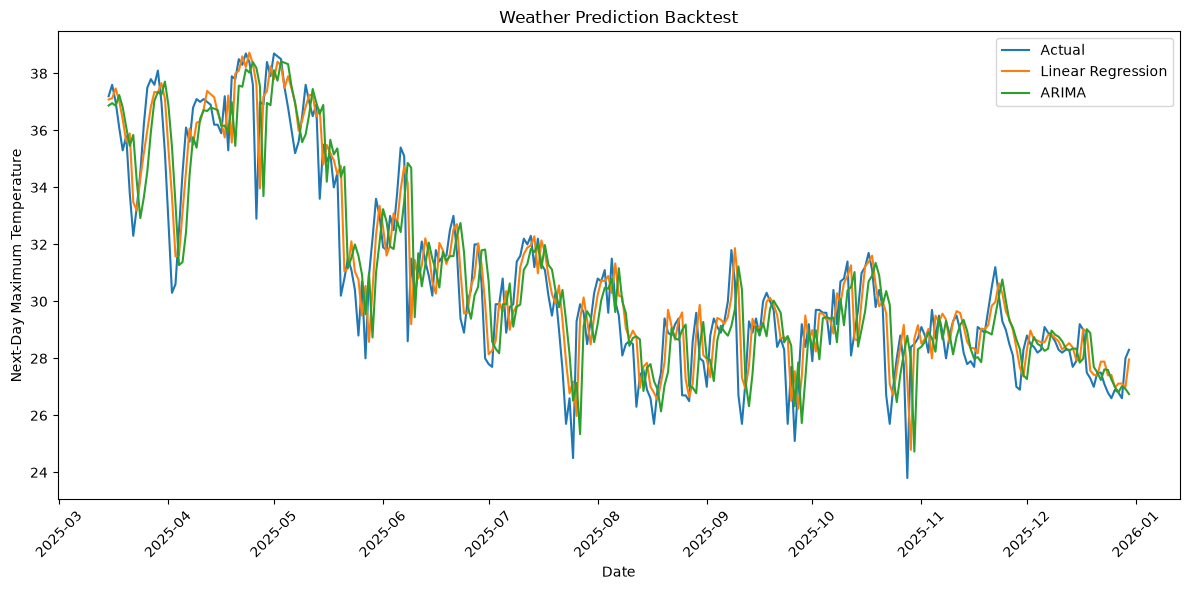

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    backtest_results["date"],
    backtest_results["actual"],
    label="Actual"
)

plt.plot(
    backtest_results["date"],
    backtest_results["predicted_regression"],
    label="Linear Regression"
)

plt.plot(
    backtest_results["date"],
    backtest_results["predicted_arima"],
    label="ARIMA"
)

plt.xlabel("Date")
plt.ylabel("Next-Day Maximum Temperature")
plt.title("Weather Prediction Backtest")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
backtest_results["regression_error"] = (
    backtest_results["actual"]
    - backtest_results["predicted_regression"]
).abs()

backtest_results.sort_values(
    "regression_error",
    ascending=False
).head(10)

,date,actual,predicted_regression,predicted_arima,regression_error
85,2025-06-08,28.6,34.145784,34.858065,5.545784
42,2025-04-26,32.9,37.618474,38.189703,4.718474
66,2025-05-20,30.2,34.755828,34.364726,4.555828
179,2025-09-10,26.7,30.507109,31.225919,3.807109
228,2025-10-29,28.4,24.787889,27.985890,3.612111
227,2025-10-28,23.8,27.194623,28.793252,3.394623
18,2025-04-02,30.3,33.686389,35.425011,3.386389
133,2025-07-26,29.3,25.978495,27.136251,3.321505
211,2025-10-12,28.1,31.267150,30.502715,3.167150
60,2025-05-14,33.6,36.730723,36.576440,3.130723


In [19]:
backtest_results["arima_error"] = (
    backtest_results["actual"]
    - backtest_results["predicted_arima"]
).abs()

backtest_results.sort_values(
    "arima_error",
    ascending=False
).head(10)

,date,actual,predicted_regression,predicted_arima,regression_error,arima_error
85,2025-06-08,28.6,34.145784,34.858065,5.545784,6.258065
42,2025-04-26,32.9,37.618474,38.189703,4.718474,5.289703
18,2025-04-02,30.3,33.686389,35.425011,3.386389,5.125011
227,2025-10-28,23.8,27.194623,28.793252,3.394623,4.993252
180,2025-09-11,25.7,27.319728,30.410151,1.619728,4.710151
134,2025-07-27,29.9,29.384185,25.340218,0.515815,4.559782
179,2025-09-10,26.7,30.507109,31.225919,3.807109,4.525919
222,2025-10-23,25.7,27.093572,29.881994,1.393572,4.181994
66,2025-05-20,30.2,34.755828,34.364726,4.555828,4.164726
17,2025-04-01,32.8,35.344135,36.873709,2.544135,4.073709


In [20]:
print(backtest_results.shape)
print(backtest_results.isnull().sum())
print(comparison)

(291, 6)
date                    0
actual                  0
predicted_regression    0
predicted_arima         0
regression_error        0
arima_error             0
dtype: int64
               Model       MAE       MSE      RMSE
0  Linear Regression  0.889169  1.508421  1.228178
1              ARIMA  1.234753  2.741936  1.655879


In [21]:
print(backtest_results.head())
print()
print(comparison)
print()
print("Shape:", backtest_results.shape)
print()
print("Missing values:")
print(backtest_results.isnull().sum())

        date  actual  predicted_regression  predicted_arima  regression_error  \
0 2025-03-15    37.2             37.084274        36.873383          0.115726   
1 2025-03-16    37.6             37.129127        36.956696          0.470873   
2 2025-03-17    37.0             37.473314        36.864422          0.473314   
3 2025-03-18    36.1             37.031483        37.242766          0.931483   
4 2025-03-19    35.3             36.384392        36.812151          1.084392   

   arima_error  
0     0.326617  
1     0.643304  
2     0.135578  
3     1.142766  
4     1.512151  

               Model       MAE       MSE      RMSE
0  Linear Regression  0.889169  1.508421  1.228178
1              ARIMA  1.234753  2.741936  1.655879

Shape: (291, 6)

Missing values:
date                    0
actual                  0
predicted_regression    0
predicted_arima         0
regression_error        0
arima_error             0
dtype: int64
